# Final Results: PartlyCloudy

> **Reproducibility note (read before running):** this notebook is one of a set of
> `0*_*.ipynb` notebooks split out of the original `compiled_results_analysis.ipynb`
> for the publication reproducibility bundle, meant to be run with the repo root (`task_dim/`) as
> the working directory. Each notebook is self-contained (re-loads its own
> inputs rather than relying on variables from other notebooks). A global `SEED = 4` is set at
> the top of the setup cell so every resampling/permutation step below is deterministic.
>
> **Inputs used here are pre-computed.** Where a cell loads a CSV/NIfTI file, a comment states
> which upstream script produced it. A few inputs this notebook depends on
> (`compiled/info/combined_participant_info.csv`, `compiled/results/*_compiled_results.csv`,
> `compiled/results/combined_corrs.csv`, `compiled/results/combined_corr_analyses.csv`) 

In [1]:
import numpy as np
import pandas as pd
import os 
import matplotlib.pyplot as plt
import seaborn as sns
import scipy.stats as stats
import statsmodels.formula.api as smf
from matplotlib import rcParams
import plotting_helpers as helper          # surface plots, colormaps, dataset colors
import stats_helpers as stats_helpers      # permutation tests, (parcelwise/LME) regression, FDR correction
from plotting_helpers import (
    load_atlas,   # Schaefer-400 atlas + region label order
    get_average_results,  # average/reindex per-region scores
)
rcParams['pdf.fonttype'] = 42
rcParams['ps.fonttype'] = 42

PLOT_DIR = 'compiled/plots'
os.makedirs(PLOT_DIR, exist_ok=True)
ISC_CMAP = 'OrRd'
ID_CMAP = helper.custom_blues_cmap()
dataset_colors = helper.dataset_colors('all')

# Global seed: makes every unseeded resample/permutation call below reproducible.
SEED = 4
np.random.seed(SEED)

## Load results and participant info; define age groupings

In [2]:
atlas_img, atlas_labels = load_atlas()
results_df_pc = pd.read_csv('compiled/results/partlycloudy_compiled_results.csv')

def get_age_groupings_pc(age):
    if age < 5: return 'U05'
    elif age < 6: return 'U06'
    elif age < 8.2: return 'U082'
    elif age < 13: return 'U13'
    else: return 'Adult'

def get_motion_pc(subject_id):
    sub_data = par_df_pc[par_df_pc['participant_id'] == subject_id]
    if not sub_data.empty:
        return sub_data['movie_FD'].values[0]
    else:
        return np.nan

par_df = pd.read_csv('compiled/info/combined_participant_info.csv')
par_df_pc = par_df[par_df['dataset'] == 'PartlyCloudy'].reset_index(drop=True)
results_df_pc['AgeGroup'] = [get_age_groupings_pc(a) for a in results_df_pc['_age_raw']]
par_df_pc['Age'] = par_df_pc['age_months'] / 12
par_df_pc['movie_FD'] = [get_motion_pc(sid) for sid in par_df_pc['participant_id']]
age_order_pc = ['U05', 'U06', 'U082', 'U13', 'Adult']

[get_dataset_dir] Dataset found in /Users/elb/nilearn_data/schaefer_2018


## Demographics: age distribution and count by AgeGroup/Gender

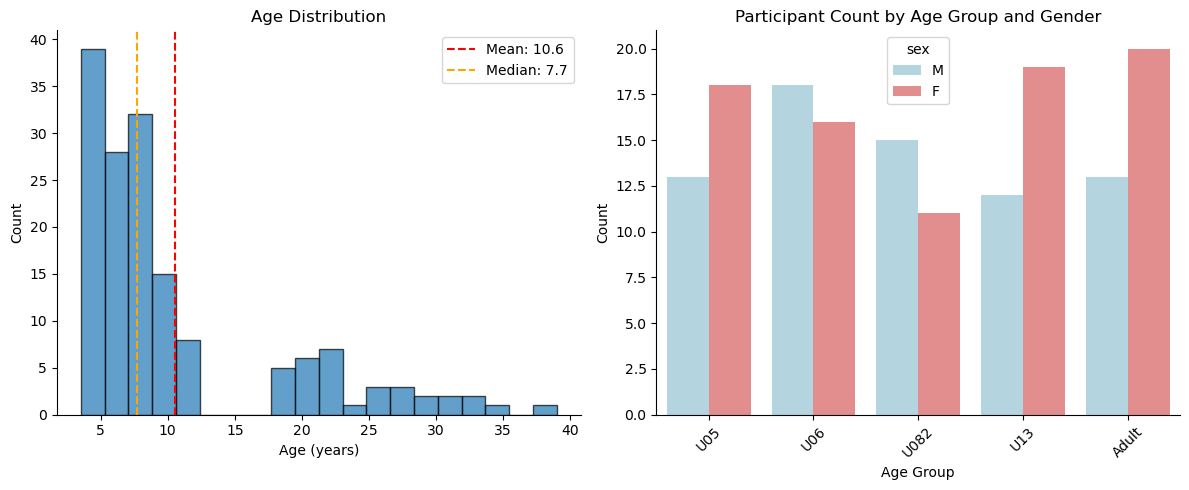

In [3]:
fig, axes = plt.subplots(1, 2, figsize=(12, 5))
ax = axes[0]
par_df_pc['Age'].hist(bins=20, alpha=0.7, ax=ax, edgecolor='black')
par_df_pc['AgeGroup'] = par_df_pc['Age'].apply(get_age_groupings_pc)
ax.set_xlabel('Age (years)'); ax.set_ylabel('Count'); ax.set_title('Age Distribution')
ax.axvline(par_df_pc['Age'].mean(), color='red', linestyle='--', label=f'Mean: {par_df_pc["Age"].mean():.1f}')
ax.axvline(par_df_pc['Age'].median(), color='orange', linestyle='--', label=f'Median: {par_df_pc["Age"].median():.1f}')
ax.legend(); ax.grid(False)
ax = axes[1]
sns.countplot(data=par_df_pc, x='AgeGroup', hue='sex', order=age_order_pc,
              palette={'F': 'lightcoral', 'M': 'lightblue'}, ax=ax)
ax.set_xlabel('Age Group'); ax.set_ylabel('Count'); ax.set_title('Participant Count by Age Group and Gender')
ax.tick_params(axis='x', rotation=45)
sns.despine(); plt.tight_layout(); plt.show()

## Motion analysis: mean FD vs Age and by AgeGroup

/var/folders/1f/s3_5gwyj4j3c18swys7lqz4w0000gn/T/ipykernel_61120/635184733.py:11: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=par_df_pc, x='AgeGroup', y='movie_FD', order=age_order_pc,
/var/folders/1f/s3_5gwyj4j3c18swys7lqz4w0000gn/T/ipykernel_61120/635184733.py:11: UserWarning: The palette list has more values (7) than needed (5), which may not be intended.
  sns.barplot(data=par_df_pc, x='AgeGroup', y='movie_FD', order=age_order_pc,
/var/folders/1f/s3_5gwyj4j3c18swys7lqz4w0000gn/T/ipykernel_61120/635184733.py:13: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.stripplot(data=par_df_pc, x='AgeGroup', y='movie_FD', order=age_order_pc,
/var/folders/1f/s3_5gwyj4j3c18swys7lqz4w0000gn/T/ipykernel

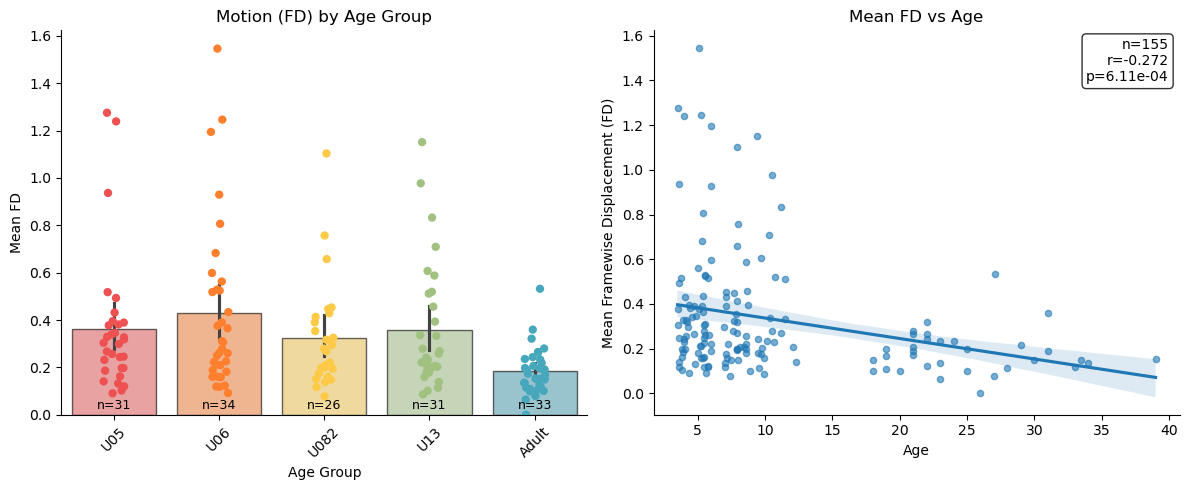

In [4]:
fig, axes = plt.subplots(1, 2, figsize=(12, 5))
ax = axes[1]
mask = par_df_pc[['Age', 'movie_FD']].notnull().all(axis=1)
x, y = par_df_pc.loc[mask, 'Age'], par_df_pc.loc[mask, 'movie_FD']
sns.regplot(data=par_df_pc.loc[mask], x='Age', y='movie_FD', ax=ax, scatter_kws={'s': 20, 'alpha': 0.6}, ci=95)
r_fd, p_fd = stats.pearsonr(x, y)
ax.text(0.98, 0.98, f'n={mask.sum()}\nr={r_fd:.3f}\np={p_fd:.2e}', transform=ax.transAxes,
        ha='right', va='top', bbox=dict(boxstyle='round', facecolor='white', alpha=0.8))
ax.set_title('Mean FD vs Age'); ax.set_ylabel('Mean Framewise Displacement (FD)')
ax = axes[0]
sns.barplot(data=par_df_pc, x='AgeGroup', y='movie_FD', order=age_order_pc,
            ax=ax, palette=helper.get_palette7_rainbow(), alpha=0.6, edgecolor='black')
sns.stripplot(data=par_df_pc, x='AgeGroup', y='movie_FD', order=age_order_pc,
              ax=ax, palette=helper.get_palette7_rainbow(), size=6, alpha=1)
age_group_counts_pc = par_df_pc['AgeGroup'].value_counts().to_dict()
for p, age_group in zip(ax.patches, age_order_pc):
    xpos = p.get_x() + p.get_width() / 2
    count = age_group_counts_pc.get(age_group, 0)
    ax.text(xpos, 0.01, f'n={count}', ha='center', va='bottom', fontsize=9)
ax.set_xlabel('Age Group'); ax.set_ylabel('Mean FD'); ax.set_title('Motion (FD) by Age Group')
ax.tick_params(axis='x', rotation=45)
sns.despine(); plt.tight_layout(); plt.show()

## 6-panel figure: mean ISC/IDE/FD by age group + vs. age (with OLS controlling for FD)

/var/folders/1f/s3_5gwyj4j3c18swys7lqz4w0000gn/T/ipykernel_61120/3830607129.py:17: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=single_isc, x='AgeGroup', y='score', ax=ax, order=age_order_pc, palette='Set2', alpha=0.6, edgecolor='black')
/var/folders/1f/s3_5gwyj4j3c18swys7lqz4w0000gn/T/ipykernel_61120/3830607129.py:18: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.stripplot(data=single_isc, x='AgeGroup', y='score', ax=ax, order=age_order_pc, size=6, alpha=1, palette='Set2')
/var/folders/1f/s3_5gwyj4j3c18swys7lqz4w0000gn/T/ipykernel_61120/3830607129.py:22: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` 

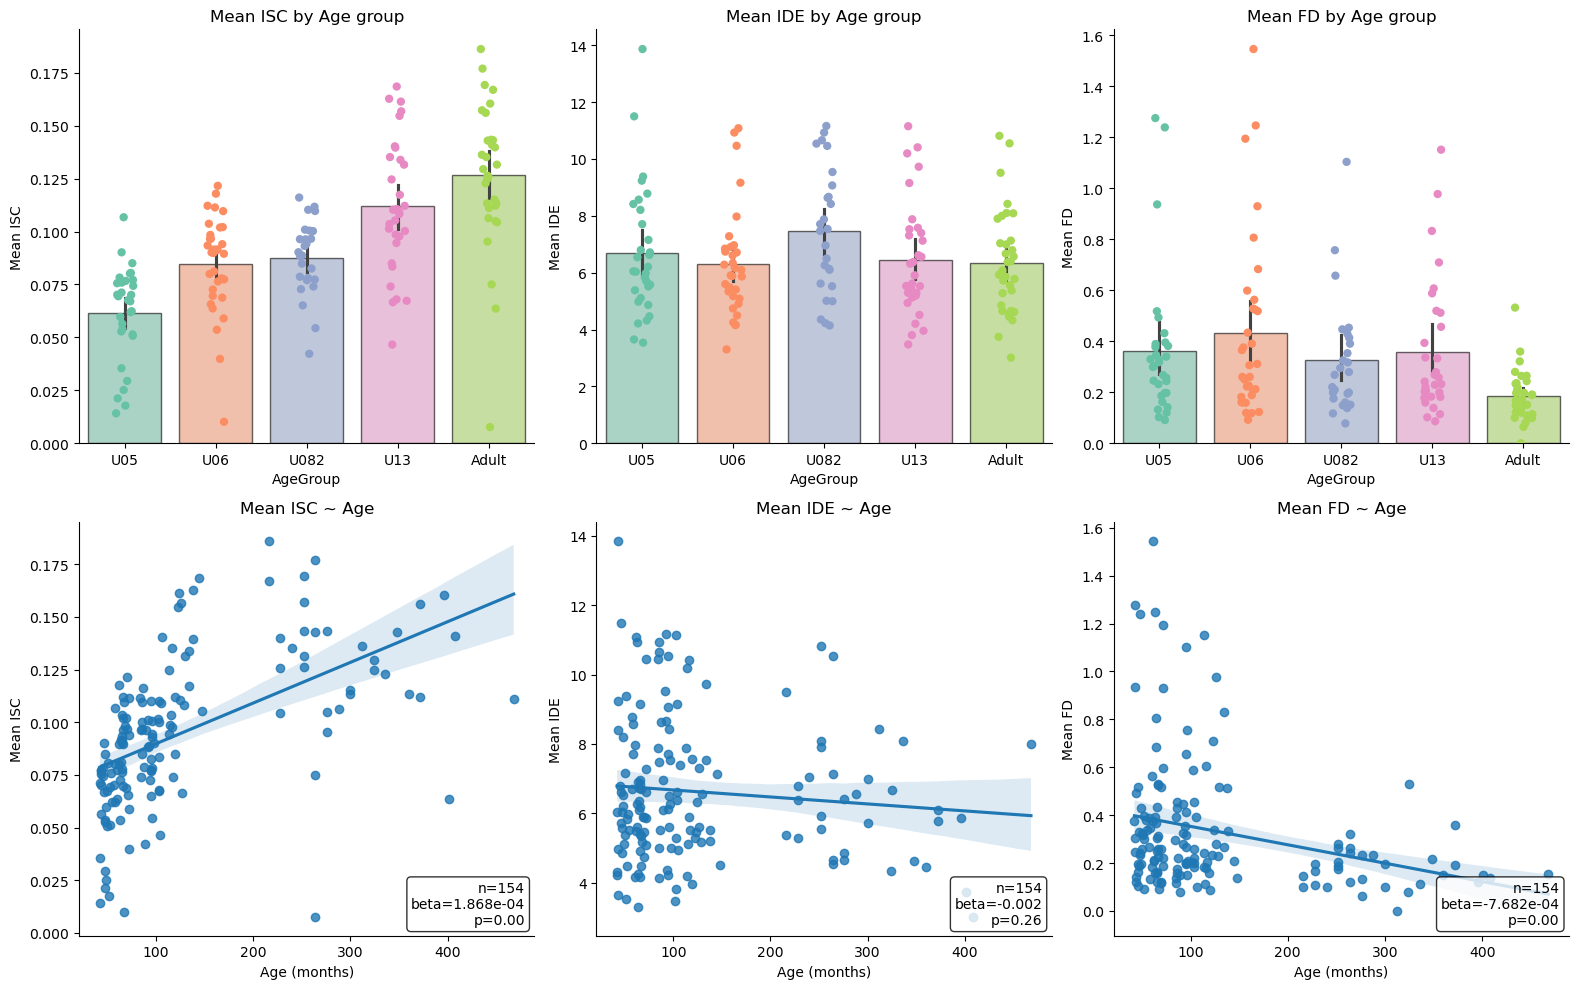

In [5]:
# Create mean ISC dataframe
task_pc = 'pixar'
df_regional_isc = results_df_pc[(results_df_pc['task'] == task_pc) & (results_df_pc['measure'] == 'ISC')].copy()
single_isc = df_regional_isc.groupby('subject_id').mean(numeric_only=True).reset_index()
single_isc['AgeGroup'] = single_isc['_age_raw'].apply(get_age_groupings_pc)
single_isc['mean_FD'] = single_isc['subject_id'].map(par_df_pc.set_index('participant_id')['movie_FD'])

# Create mean IDE dataframe
df_regional_ide = results_df_pc[(results_df_pc['task'] == task_pc) & (results_df_pc['measure'] == 'TPHATE_DiffOp_IDE')].copy()
single_ide = df_regional_ide.groupby('subject_id').mean(numeric_only=True).reset_index()
single_ide['AgeGroup'] = single_ide['_age_raw'].apply(get_age_groupings_pc)
single_ide['mean_FD'] = single_ide['subject_id'].map(par_df_pc.set_index('participant_id')['movie_FD'])

fig, axes = plt.subplots(2, 3, figsize=(16, 10))
# Mean ISC by age group
ax = axes[0, 0]
sns.barplot(data=single_isc, x='AgeGroup', y='score', ax=ax, order=age_order_pc, palette='Set2', alpha=0.6, edgecolor='black')
sns.stripplot(data=single_isc, x='AgeGroup', y='score', ax=ax, order=age_order_pc, size=6, alpha=1, palette='Set2')
ax.set_ylabel('Mean ISC'); ax.set_title('Mean ISC by Age group')
# Mean IDE by age group
ax = axes[0, 1]
sns.barplot(data=single_ide, x='AgeGroup', y='score', ax=ax, order=age_order_pc, palette='Set2', alpha=0.6, edgecolor='black')
sns.stripplot(data=single_ide, x='AgeGroup', y='score', ax=ax, order=age_order_pc, size=6, alpha=1, palette='Set2')
ax.set_ylabel('Mean IDE'); ax.set_title('Mean IDE by Age group')

# Scatter plot of ISC vs age with regression line; OLS controlling for FD (statsmodels.formula.api.ols)
ax = axes[1, 0]
sns.regplot(data=single_isc, x='age_months', y='score', ax=ax)
ols1 = smf.ols('score ~ age_months + mean_FD', data=single_isc).fit()
beta_age_isc = ols1.params['age_months']; p_age_isc = ols1.pvalues['age_months']
ax.text(0.98, 0.02, f'n={len(single_isc)}\nbeta={beta_age_isc:.3e}\np={p_age_isc:.2f}', transform=ax.transAxes,
         ha='right', va='bottom', bbox=dict(boxstyle='round', facecolor='white', alpha=0.8))
ax.set_xlabel('Age (months)'); ax.set_ylabel('Mean ISC'); ax.set_title('Mean ISC ~ Age')

# Scatter plot of IDE vs age with regression line
ax = axes[1, 1]
sns.regplot(data=single_ide, x='age_months', y='score', ax=ax)
ols2 = smf.ols('score ~ age_months + mean_FD', data=single_ide).fit()
beta_age_id = ols2.params['age_months']; p_age_id = ols2.pvalues['age_months']
ax.text(0.98, 0.02, f'n={len(single_ide)}\nbeta={beta_age_id:.3f}\np={p_age_id:.2f}', transform=ax.transAxes,
         ha='right', va='bottom', bbox=dict(boxstyle='round', facecolor='white', alpha=0.8))
ax.set_xlabel('Age (months)'); ax.set_ylabel('Mean IDE'); ax.set_title('Mean IDE ~ Age')
sns.despine(); plt.tight_layout()

# Mean FD by age group
ax = axes[0, 2]
sns.barplot(data=single_ide, x='AgeGroup', y='mean_FD', ax=ax, order=age_order_pc, palette='Set2', alpha=0.6, edgecolor='black')
sns.stripplot(data=single_ide, x='AgeGroup', y='mean_FD', ax=ax, order=age_order_pc, size=6, alpha=1, palette='Set2')
ax.set_ylabel('Mean FD'); ax.set_title('Mean FD by Age group')

# Scatter plot of FD vs age with regression line
ax = axes[1, 2]
sns.regplot(data=single_isc, x='age_months', y='mean_FD', ax=ax)
ols3 = smf.ols('mean_FD ~ age_months', data=single_isc).fit()
beta_age_fd = ols3.params['age_months']; p_age_fd = ols3.pvalues['age_months']
ax.text(0.98, 0.02, f'n={len(single_isc)}\nbeta={beta_age_fd:.3e}\np={p_age_fd:.2f}', transform=ax.transAxes,
         ha='right', va='bottom', bbox=dict(boxstyle='round', facecolor='white', alpha=0.8))
ax.set_xlabel('Age (months)'); ax.set_ylabel('Mean FD'); ax.set_title('Mean FD ~ Age')
plt.savefig(f'{PLOT_DIR}/partlycloudy_means_by_age.pdf', format='pdf', transparent=True); plt.show()

## Surface grid by AgeGroup (ISC and IDE)

In [6]:
results_dfa_pc = results_df_pc[results_df_pc['task'] == task_pc]
df_pc_surf = results_dfa_pc[results_dfa_pc['measure'].isin(['ISC', 'TPHATE_DiffOp_IDE'])].copy()
mean_by_pc = df_pc_surf.groupby(['AgeGroup', 'measure', 'region_name'])['score'].agg(
    lambda x: x.mean(skipna=True)).reset_index()

data_arrs_pc, titles_pc, img_fns_pc = [], [], []
for m in ['ISC', 'TPHATE_DiffOp_IDE']:
    for age in age_order_pc:
        s = get_average_results(mean_by_pc, col_names=['AgeGroup', 'measure'], target_names=[age, m],
                                 value_name='score', region_name_order=atlas_labels)
        data_arrs_pc.append(s)
        titles_pc.append(f"{age} {'ISC' if m == 'ISC' else 'IDE'}")
        img_fns_pc.append(f'PartlyCloudy/plots/{task_pc}_{age}_{m}.png')

helper.compile_surface_plots_to_grid_by_rows(
    img_fns_pc, data_arrs_pc,
    output_path=f'{PLOT_DIR}/partlycloudy_agegroup_isc_ide_surface_grid.pdf',
    n_rows=2, surf_type='fslr', target_density='32k', method='linear',
    atlas='Schaefer', rerun=True,
    cmaps_per_row=[ISC_CMAP, ID_CMAP],
    cbar_ranges_per_row=[[0.0, 0.3], [1, 16]],
    cbar_labels_per_row=['ISC', 'IDE'],
    titles=titles_pc
)

Rerunning surface plot generation for 10 images.
[get_dataset_dir] Dataset found in /Users/elb/nilearn_data/schaefer_2018
Generated surface plot: PartlyCloudy/plots/pixar_U05_ISC.png
[get_dataset_dir] Dataset found in /Users/elb/nilearn_data/schaefer_2018
Generated surface plot: PartlyCloudy/plots/pixar_U06_ISC.png
[get_dataset_dir] Dataset found in /Users/elb/nilearn_data/schaefer_2018
Generated surface plot: PartlyCloudy/plots/pixar_U082_ISC.png
[get_dataset_dir] Dataset found in /Users/elb/nilearn_data/schaefer_2018
Generated surface plot: PartlyCloudy/plots/pixar_U13_ISC.png
[get_dataset_dir] Dataset found in /Users/elb/nilearn_data/schaefer_2018
Generated surface plot: PartlyCloudy/plots/pixar_Adult_ISC.png
[get_dataset_dir] Dataset found in /Users/elb/nilearn_data/schaefer_2018
Generated surface plot: PartlyCloudy/plots/pixar_U05_TPHATE_DiffOp_IDE.png
[get_dataset_dir] Dataset found in /Users/elb/nilearn_data/schaefer_2018
Generated surface plot: PartlyCloudy/plots/pixar_U06_TPHA

'compiled/plots/partlycloudy_agegroup_isc_ide_surface_grid.pdf'

## ISC-IDE permutation correlation per subject, and z-score vs Age

In [7]:
# INPUT: compiled/results/combined_corrs.csv -- per-subject ISC-IDE permutation correlation
#   z-scores (stats_helpers.permute_pattern / stats_helpers.within_subject_spearman).
#   See REPRODUCIBILITY.md.
df_corr_pc = pd.read_csv('compiled/results/combined_corrs.csv')
df_corr_pc = df_corr_pc[df_corr_pc['dataset'] == 'PartlyCloudy'].reset_index(drop=True)
print(f"ISC-IDE correlation computed for {len(df_corr_pc)} subjects")
df_corr_pc['AgeGroup'] = [get_age_groupings_pc(a / 12) for a in df_corr_pc['age_months']]
df_corr_pc.head()

ISC-IDE correlation computed for 154 subjects


,dataset,participant_id,modality,zscore,age_months,FD,zscore_zscored,AgeGroup
0,PartlyCloudy,sub-pixar001,V,3.622246,57.297741,0.389254,-0.196835,U05
1,PartlyCloudy,sub-pixar002,V,3.939167,58.283368,0.345567,-0.087916,U05
2,PartlyCloudy,sub-pixar003,V,2.164586,49.839836,0.327122,-0.697799,U05
3,PartlyCloudy,sub-pixar004,V,2.429890,53.683778,0.381298,-0.606620,U05
4,PartlyCloudy,sub-pixar005,V,6.238120,58.053388,0.131736,0.702182,U05


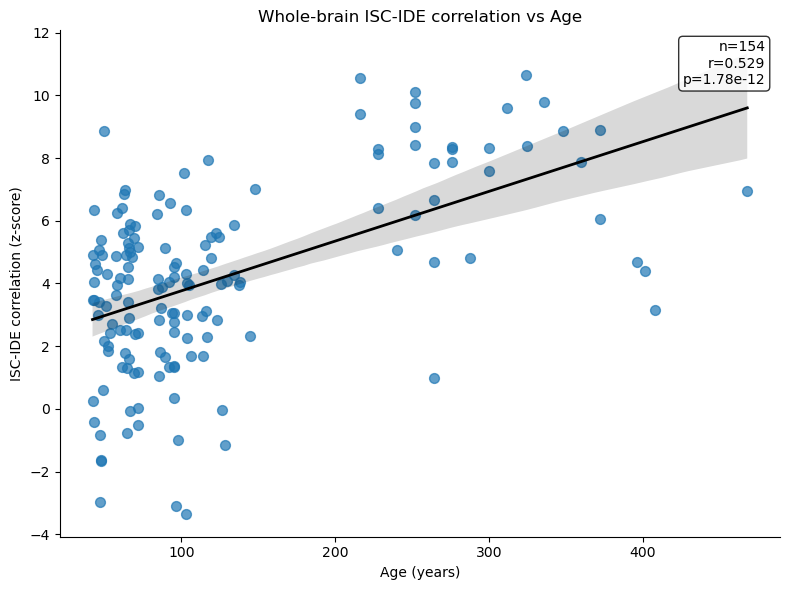

In [8]:
plt.figure(figsize=(8, 6))
sns.regplot(data=df_corr_pc, x='age_months', y='zscore', scatter_kws={'s': 50, 'alpha': 0.7},
            line_kws={'color': 'k', 'linewidth': 2})
r_overall, p_overall = stats.pearsonr(df_corr_pc['age_months'], df_corr_pc['zscore'])
plt.title('Whole-brain ISC-IDE correlation vs Age')
plt.text(0.98, 0.98, f'n={len(df_corr_pc)}\nr={r_overall:.3f}\np={p_overall:.2e}',
         transform=plt.gca().transAxes, ha='right', va='top',
         bbox=dict(boxstyle='round', facecolor='white', alpha=0.8))
plt.xlabel('Age (years)'); plt.ylabel('ISC-IDE correlation (z-score)')
sns.despine(); plt.tight_layout()
plt.savefig(f'{PLOT_DIR}/partlycloudy_isc_ide_corr_vs_age_scatter.pdf', format='pdf', transparent=True)
plt.show()

## Subject-level table with FD and sex merged in (used by pooled notebooks)

In [1]:
# INPUT: compiled/results/combined_corr_analyses.csv 
temp = pd.read_csv('compiled/results/combined_corr_analyses.csv')
temp_pc = temp[temp['dataset'] == 'partlycloudy']
results_df_pc['mean_FD'] = results_df_pc['subject_id'].map(temp_pc.set_index('subject')['movie_FD'])
results_df_pc['sex'] = results_df_pc['subject_id'].map(temp_pc.set_index('subject')['sex'])
REGION_ORDER_PC = results_df_pc['region_name'].values[:400]
dataframe_pc = results_df_pc.pivot_table(
    index=['subject_id', 'region_name', 'task', 'age_months', '_age_raw', 'mean_FD', 'sex'],
    columns='measure', values='score').reset_index()
dataframe_pc.head()

NameError: name 'pd' is not defined